# Problems: Kernel Density Estimation

**Problem 1.** Suppose the data are `[1, 1.75, 2, 3, 3.25, 4]`.

- a. Sketch the empirical cumulative distribution function.
- b. Sketch the uniform kernel density estimator for a bandwidth of `h = 0.2`
- c. Compute the Silverman bandwidth for the uniform kernel using `h = 1.84 * SD * n**(-0.2)`.
- d. Sketch the uniform kernel density estimator for the Silverman bandwidth.
- e. How are b and d similar or different?

### 1a

In [1]:
import numpy as np
import matplotlib.pyplot as plt

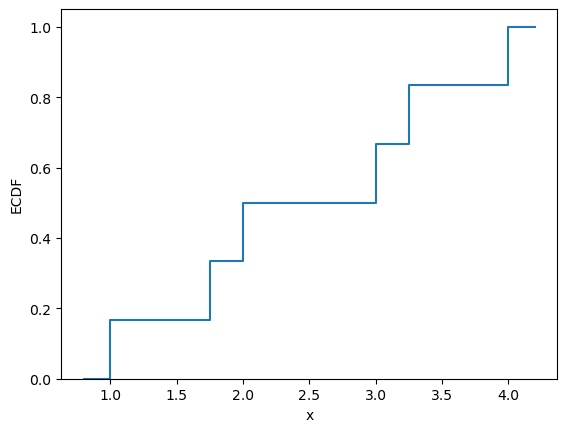

In [4]:
plt.step(
    np.r_[0.8, x, 4.2],
    np.r_[0, y, 1],
    where="post"
)

plt.xlabel("x")
plt.ylabel("ECDF")
plt.ylim(0, 1.05)
plt.show()

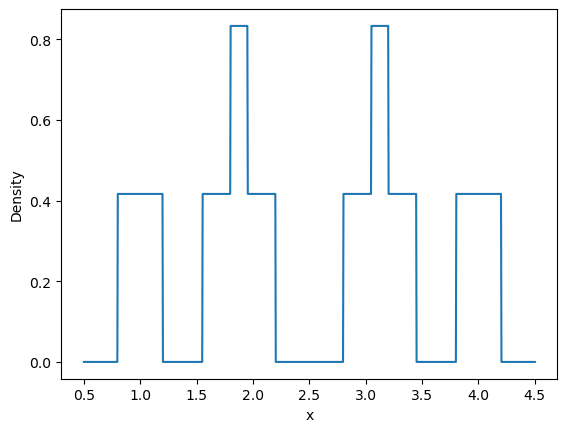

In [19]:
### 1b
h = 0.2
grid = np.linspace(0.5, 4.5, 1000)
kde = np.zeros_like(grid)

for xi in x:
    kde += (np.abs(grid - xi) <= h) / (2 * h * len(x))

plt.plot(grid, kde)
plt.xlabel("x")
plt.ylabel("Density")
plt.show()


### 1c

In [18]:
SD = np.std(x, ddof=1)
n = len(x)
h_silverman = 1.84 * SD * n**(-0.2)

print("SD:", SD)
print("Silverman bandwidth:", h_silverman)

SD: 1.1067971810589328
Silverman bandwidth: 1.4231661885912126


### 1d

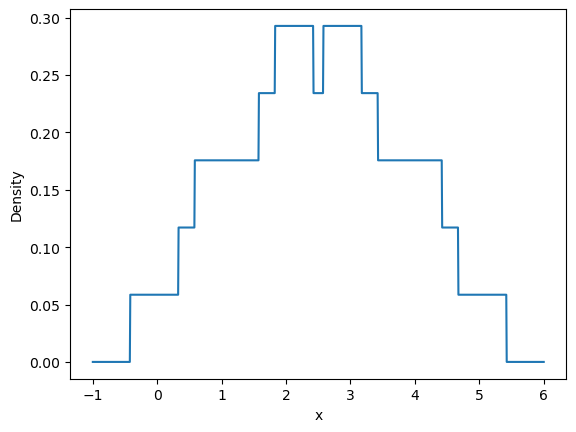

In [17]:
h = h_silverman
grid = np.linspace(-1, 6, 1000)
kde = np.zeros_like(grid)

for xi in x:
    kde += (np.abs(grid - xi) <= h) / (2 * h * len(x))

plt.plot(grid, kde)
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

### 1e

Both b and d use a uniform kernel. The smaller bandwidth in problem b had a more detailed estimate with narrow peaks. Problem d had a larger bandwidth which made the KDE smoother and a bit wider

**Problem 2.** Suppose the data `X = [-1, -0.5, 0, 0.5, 1]` were drawn from a standard Normal distribution.

- a. Using the uniform kernel with `h = 0.6`, compute the realized KDE at `x = 0`, `f_hat_h(0)`, directly from these five numbers.
- b. Now compute `E[f_hat_h(0)]` at the same `h = 0.6`.
- c. Calculate the true density at `x=0`, using the Normal distribution.
- d. Are b and c equal? What does this mean about bias? (Keep in mind, truly proving anything about bias would require us to compare `E[f_hat_h]` to the Normal distribution for all x; calculating this at one point is only an indication of what is going on that you can extrapolate from.)
- e. Recompute `E[f_hat_h(0)]` from (b) at a much smaller bandwidth, `h = 0.1`. What happens to the gap between `E[f_hat_h(0)]` and `f(0)` as `h` shrinks?
- f. Is `f_hat_h` a consistent estimator? Explain your reasoning.
- g. What are the main considerations in choosing a bandwidth value `h`?

### 2a

In [8]:
X = np.array([-1, -0.5, 0, 0.5, 1])
h = 0.6
x0 = 0

within_bandwidth = np.abs(X - x0) <= h
f_hat = np.sum(within_bandwidth) / (2 * len(X) * h)

print("Points within bandwidth:", X[within_bandwidth])
print("KDE at x = 0:", f_hat)

Points within bandwidth: [-0.5  0.   0.5]
KDE at x = 0: 0.5


### 2b

In [16]:
from scipy.stats import norm

h = 0.6
probability = norm.cdf(h) - norm.cdf(-h)
expected_kde = probability / (2 * h)

print("Expected KDE at x = 0:", expected_kde)

Expected KDE at x = 0: 0.3762448037498774


### 2c

In [10]:
true_density = norm.pdf(0)

print("True density at x = 0:", true_density)

True density at x = 0: 0.3989422804014327


### 2d

No, they aren't equal. The expected KDE is a little lower than the true density at x=0. This probably suggests a downward bias for the KDE

### 2e

In [15]:
h = 0.1
probability = norm.cdf(h) - norm.cdf(-h)
expected_kde = probability / (2 * h)

print("Expected KDE at x = 0:", expected_kde)

Expected KDE at x = 0: 0.3982783727702899


The gap between `E[f_hat_h(0)]` and `f(0)`gets smaller as h decreases

### 2f

YES, it is a consistent estimator because the KDE appraoches true density when sample size increases and the bandwidth decreases.

### 2g

A smaller bandwidth means less bias, more detail, narrow kernels, and more variance. A larger bandwidth means more bias, less detail, smoother curves, wider kernels, and less variance. The bandwidth needs to be a balance of both.

**Problem 3.** Suppose the data are `X = [5, 7, 7, 8, 10]`, and fix the bandwidth at `h = 1.5` for both kernels below.

- a. Compute the uniform-kernel KDE, `f_hat_h(x)`, at `x = 6.0`, `x = 6.5`, `x = 7.0`, `x = 8.0`, and `x = 8.5`.
- b. Compute the Gaussian-kernel KDE at the same five values of `x`, using the same `h = 1.5`.
- c. Your part (a) values should jump abruptly between some of these five points, while your part (b) values should change smoothly. Identify where the biggest jump in (a) happens, and explain in terms of the two kernel *shapes* -- not just "one is smoother" -- why that jump exists in the uniform case but not the Gaussian case.
- d. Why might you prefer one kernel over the other in practice?


### 3a

In [12]:
X = np.array([5, 7, 7, 8, 10])
h = 1.5
x_values = np.array([6, 6.5, 7, 8, 8.5])

uniform_kde = []

for x0 in x_values:
    within_bandwidth = np.abs(X - x0) <= h
    f_hat = np.sum(within_bandwidth) / (2 * len(X) * h)
    uniform_kde.append(f_hat)

for x0, density in zip(x_values, uniform_kde):
    print(x0, density)

6.0 0.2
6.5 0.26666666666666666
7.0 0.2
8.0 0.2
8.5 0.26666666666666666


### 3b

In [13]:
from scipy.stats import norm

gaussian_kde = []

for x0 in x_values:
    density = np.mean(norm.pdf((x0 - X) / h)) / h
    gaussian_kde.append(density)

for x0, density in zip(x_values, gaussian_kde):
    print(x0, density)

6.0 0.15116667696891303
6.5 0.16865730580239766
7.0 0.17804448100191994
8.0 0.16744524435137584
8.5 0.1506023053792177


### 3c

The biggest jumps in part a happen at 6 to 6.5, 6.5 to 7, and 8 to 8.5. The uniform kernel jumps because the points either fall inside or outside the bandwidth. The Gaussian kernel has a more gradual change because the weights change more smoothly.

### 3d

The gaussian kernel may be preferred if a smootehr curve is what you are lookign for. A uniform kernel may be preferred if you want it more simple. 

**Problem 4.** Load `./data/heart_failure_clinical_records_dataset.csv`.

- a. Plot a
-  kernel density estimate of `ejection_fraction`.
- b. Use Pandas' `df.sample(frac=1.0, replace=True)` to resample the data 15 times with replacement, plotting the kernel density estimtes for each sample.
- c. For what values of `ejection_fraction` is the original plot reliable? For which values is there noticeable variation in your plots of the resampled data?

### 4a

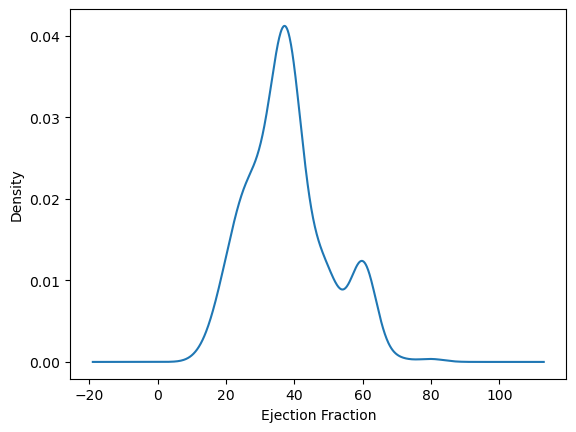

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data/heart_failure_clinical_records_dataset.csv")
df["ejection_fraction"].plot.kde()

plt.xlabel("Ejection Fraction")
plt.show()

### 4b

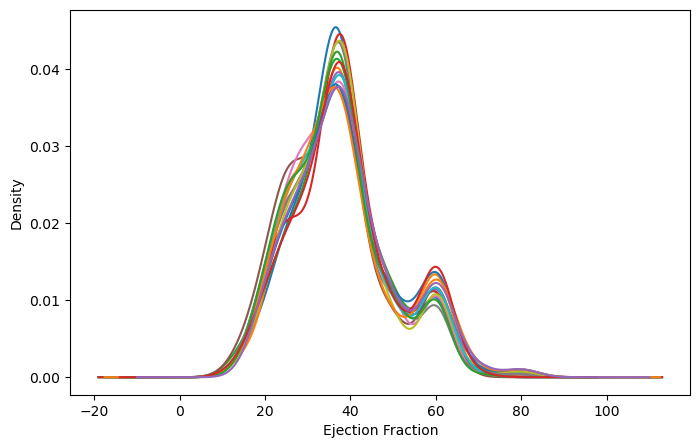

In [20]:
plt.figure(figsize=(8, 5))

for i in range(15):
    sample = df.sample(frac=1.0, replace=True)
    sample["ejection_fraction"].plot.kde()

plt.xlabel("Ejection Fraction")
plt.ylabel("Density")
plt.show()

### 4c

The orginal KDE plot is reliable becuase the resampled plots look very similar. There is noticeable variation around the peaks and dips, specifically around the ejection fraction values of 20-25, 35-45, 55-65. 

I used gen AI to help troubleshoot coding errors 